# Dungeon Delivery Tournament Dashboard

Run a baseline tournament, inspect scores, and plot cumulative performance.

In [1]:
from dungeon_delivery.tournament import default_baseline_agents, run_tournament
from dungeon_delivery.dashboard import scores_dataframe, score_by_round_dataframe, plot_scores_by_round

result = run_tournament(default_baseline_agents(seed=0), rounds=25, seed=0)
scores_dataframe(result)

,agent,total_score,average_score,deliveries,invalid_actions,errors,delayed_turns
0,opportunistic,594,23.76,24,0,0,26
1,astar,512,20.48,21,0,0,14
2,nearest,424,16.96,21,0,0,68
3,greedy,354,14.16,13,0,0,32
4,random,0,0.00,0,0,0,126


In [2]:
score_by_round_dataframe(result).head()

,round,agent,score,map
0,0,random,0,portal_map
1,0,nearest,0,portal_map
2,0,greedy,22,portal_map
3,0,astar,28,portal_map
4,0,opportunistic,18,portal_map


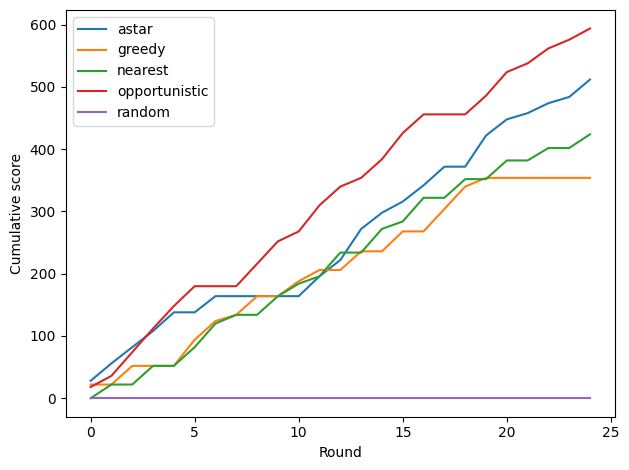

In [3]:
plot_scores_by_round(result)

## Replay a Round

Each game result stores one lightweight snapshot before play starts and after every scheduled turn. You can inspect those snapshots as ASCII in the notebook, or launch the optional pygame replay viewer.

In [4]:
from dungeon_delivery.dashboard import ascii_replay

round_result = result.round_results[0]
frames = ascii_replay(round_result, every=5)
print(f"{len(round_result.snapshots)} recorded snapshots; showing every 5th frame")
for i, frame in enumerate(frames[:6]):
    print(f"\n--- Frame {i} ---")
    print(frame)

78 recorded snapshots; showing every 5th frame

--- Frame 0 ---
################
#*..0P...#...x.#
#.####.#.#.###.#
#......#.#..P1.#
#.######.###.#.#
#.x..1......#0.#
#.P.........x..#
################

--- Frame 1 ---
################
#SO.0P...#...x.#
#*####.#.#.###.#
#......#.#..P1.#
#.######.###.#.#
#.x..1......#0.#
#.P.........x..#
################

--- Frame 2 ---
################
#R.O0P...#...x.#
#.####.#.#.###.#
#*.....#.#..P1.#
#.######.###.#.#
#.x..1......#0.#
#.P.........x..#
################

--- Frame 3 ---
################
#R..0P...#...x.#
#.####.#.#.###.#
#......#.#..P1.#
#*######.###.#.#
#.x..1......#O.#
#.P.........x..#
################

--- Frame 4 ---
################
#S..0P...#...x.#
#R####.#.#.###.#
#......#.#..P1.#
#.######.###.#.#
#*x..1......#0.#
#.P.........xO.#
################

--- Frame 5 ---
################
#S..OP...#...x.#
#.####.#.#.###.#
#R.....#.#..P1.#
#.######.###.#.#
#.A..1......#0.#
#*P.........x..#
################


## Optional Pygame Replay

Install the visual extra first if needed:

```bash
pip install -e ".[visual]"
```

The next cell opens a separate pygame window. Controls: Space pauses, Left/Right steps, R or REPLAY restarts, SELECT GAME returns to the menu, Esc or EXIT quits.

In [5]:
from dungeon_delivery.pygame_viewer import replay_tournament

# This opens an external pygame window with a round-selection menu.
# If pygame is not installed, run: %pip install -e ".[visual]"
replay_tournament(result, fps=5)

pygame 2.6.1 (SDL 2.28.4, Python 3.10.20)
Hello from the pygame community. https://www.pygame.org/contribute.html
